# 04 - Gaussian Processes: Learning the Kernel from the Data

**Advanced Machine Learning** | Haydar Kilic

A Gaussian process places a prior *over functions*: any finite set of inputs has
a joint Gaussian distribution, $f \sim \mathcal{GP}(0, k)$. With Gaussian noise
the posterior is available in closed form,

$$\mu_\star = K_\star (K + \sigma_n^2 I)^{-1} y, \qquad
\Sigma_\star = K_{\star\star} - K_\star (K + \sigma_n^2 I)^{-1} K_\star^\top ,$$

and so is the evidence, which is what lets us *learn* the kernel:

$$\log p(y\mid X,\theta) = -\tfrac12 y^\top K_y^{-1} y - \tfrac12\log|K_y| - \tfrac n2 \log 2\pi .$$

The first term rewards fit, the second penalises complex covariance structures:
Occam's razor falls out of the algebra instead of being imposed by hand.

In [1]:
# =========================================================================
# Toolkit for this lecture: the implementations used below, inlined so the
# notebook runs on its own (NumPy / SciPy / Matplotlib only).
# Read them alongside the derivations -- each block mirrors one formula.
# =========================================================================
from __future__ import annotations

import numpy as np
from scipy.linalg import cho_factor, cho_solve, cholesky
from scipy.optimize import minimize

# --- datasets ------------------------------------------------------

def _rng(random_state: int | np.random.Generator | None) -> np.random.Generator:
    if isinstance(random_state, np.random.Generator):
        return random_state
    return np.random.default_rng(random_state)

def make_sine(n_samples=100, noise=0.2, x_range=(-3.0, 3.0), random_state=None):
    r"""1-D regression problem :math:`y = \sin(x) + \varepsilon`."""
    rng = _rng(random_state)
    X = rng.uniform(x_range[0], x_range[1], size=(n_samples, 1))
    y = np.sin(X[:, 0]) + noise * rng.standard_normal(n_samples)
    return X, y

# --- metrics -------------------------------------------------------

def mse(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return float(np.mean((y_true - y_pred) ** 2))

def interval_coverage(y_true, lower, upper):
    """Empirical share of targets inside ``[lower, upper]``."""
    y_true = np.asarray(y_true, float)
    lower, upper = np.asarray(lower, float), np.asarray(upper, float)
    return float(np.mean((y_true >= lower) & (y_true <= upper)))

# --- gp ------------------------------------------------------------

class GaussianProcessRegressor:
    """Exact GP regression with an ARD-RBF kernel and learned noise level.

    Parameters
    ----------
    length_scale, signal_std, noise_std
        Initial hyper-parameter values (``length_scale`` may be a scalar or one
        value per feature for ARD).
    optimize
        If ``True``, maximise the log marginal likelihood; otherwise the initial
        values are kept fixed.
    n_restarts
        Extra randomised restarts of the optimiser.
    """

    def __init__(self, length_scale=1.0, signal_std=1.0, noise_std=0.1, optimize=True,
                 n_restarts=3, jitter=1e-10, random_state=None):
        self.length_scale = length_scale
        self.signal_std = float(signal_std)
        self.noise_std = float(noise_std)
        self.optimize = optimize
        self.n_restarts = int(n_restarts)
        self.jitter = float(jitter)
        self.random_state = random_state

    # ---------------------------------------------------------------- kernel
    def _kernel(self, X, Y, length_scale, signal_std):
        Xs = X / length_scale
        Ys = Y / length_scale
        d2 = np.maximum(
            (Xs**2).sum(1)[:, None] + (Ys**2).sum(1)[None, :] - 2.0 * Xs @ Ys.T, 0.0
        )
        return signal_std**2 * np.exp(-0.5 * d2)

    def _unpack(self, theta, n_features):
        params = np.exp(theta)
        length_scale = params[:n_features]
        return length_scale, params[n_features], params[n_features + 1]

    # ----------------------------------------------------- marginal likelihood
    def _nll_and_grad(self, theta, X, y):
        n, d = X.shape
        length_scale, signal_std, noise_std = self._unpack(theta, d)
        K_signal = self._kernel(X, X, length_scale, signal_std)
        K = K_signal + (noise_std**2 + self.jitter) * np.eye(n)
        try:
            L = cholesky(K, lower=True)
        except np.linalg.LinAlgError:
            return 1e25, np.zeros_like(theta)

        alpha = cho_solve((L, True), y)
        nll = 0.5 * y @ alpha + np.sum(np.log(np.diag(L))) + 0.5 * n * np.log(2 * np.pi)

        K_inv = cho_solve((L, True), np.eye(n))
        W = np.outer(alpha, alpha) - K_inv  # d(log p)/dK

        grad = np.empty_like(theta)
        Xs = X / length_scale
        for k in range(d):
            diff2 = (Xs[:, k, None] - Xs[None, :, k]) ** 2
            dK = K_signal * diff2  # d K / d log(length_scale_k)
            grad[k] = -0.5 * np.sum(W * dK)
        grad[d] = -0.5 * np.sum(W * (2.0 * K_signal))            # d/d log signal_std
        grad[d + 1] = -0.5 * np.trace(W) * 2.0 * noise_std**2    # d/d log noise_std
        return float(nll), grad

    def log_marginal_likelihood(self, X=None, y=None):
        """Log marginal likelihood at the current hyper-parameters."""
        X = self.X_train_ if X is None else np.asarray(X, float)
        y = self.y_train_ if y is None else np.asarray(y, float)
        theta = self._current_theta(X.shape[1])
        return -self._nll_and_grad(theta, X, y)[0]

    def _current_theta(self, n_features):
        ls = np.broadcast_to(np.asarray(self.length_scale, float), (n_features,))
        return np.log(np.concatenate([ls, [self.signal_std, self.noise_std]]))

    # ------------------------------------------------------------------- fit
    def fit(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y, float)
        self._y_mean = y.mean()
        y_centered = y - self._y_mean
        n, d = X.shape

        theta0 = self._current_theta(d)
        if self.optimize:
            rng = np.random.default_rng(self.random_state)
            bounds = [(np.log(1e-4), np.log(1e4))] * len(theta0)
            candidates = [theta0] + [
                theta0 + rng.normal(0.0, 1.0, size=len(theta0)) for _ in range(self.n_restarts)
            ]
            best = None
            for start in candidates:
                res = minimize(
                    self._nll_and_grad, np.clip(start, bounds[0][0], bounds[0][1]),
                    args=(X, y_centered), jac=True, method="L-BFGS-B", bounds=bounds,
                )
                if best is None or res.fun < best.fun:
                    best = res
            theta0 = best.x
            self.log_marginal_likelihood_value_ = float(-best.fun)
        else:
            self.log_marginal_likelihood_value_ = float(
                -self._nll_and_grad(theta0, X, y_centered)[0]
            )

        ls, signal_std, noise_std = self._unpack(theta0, d)
        self.length_scale_, self.signal_std_, self.noise_std_ = ls, signal_std, noise_std

        K = self._kernel(X, X, ls, signal_std) + (noise_std**2 + self.jitter) * np.eye(n)
        self._chol = cho_factor(K, lower=True)
        self.alpha_ = cho_solve(self._chol, y_centered)
        self.X_train_, self.y_train_ = X, y
        return self

    # --------------------------------------------------------------- predict
    def predict(self, X, return_std=False, return_cov=False):
        X = np.asarray(X, float)
        K_star = self._kernel(X, self.X_train_, self.length_scale_, self.signal_std_)
        mean = K_star @ self.alpha_ + self._y_mean
        if not (return_std or return_cov):
            return mean

        v = cho_solve(self._chol, K_star.T)
        K_ss = self._kernel(X, X, self.length_scale_, self.signal_std_)
        cov = K_ss - K_star @ v
        if return_cov:
            return mean, cov
        var = np.maximum(np.diag(cov), 0.0)
        return mean, np.sqrt(var)

    def sample_y(self, X, n_samples=5, random_state=None):
        """Draw functions from the posterior (noise-free) at ``X``."""
        mean, cov = self.predict(X, return_cov=True)
        rng = np.random.default_rng(random_state)
        cov = cov + 1e-9 * np.eye(len(X))
        L = cholesky(cov, lower=True)
        return mean[:, None] + L @ rng.standard_normal((len(X), n_samples))

    def sample_prior(self, X, n_samples=5, random_state=None):
        """Draw functions from the prior -- useful for showing kernel behaviour."""
        X = np.asarray(X, float)
        d = X.shape[1]
        ls = np.broadcast_to(np.asarray(self.length_scale, float), (d,))
        K = self._kernel(X, X, ls, self.signal_std) + 1e-9 * np.eye(len(X))
        L = cholesky(K, lower=True)
        rng = np.random.default_rng(random_state)
        return L @ rng.standard_normal((len(X), n_samples))

# --- viz -----------------------------------------------------------

PALETTE = ["#1f4e79", "#c0392b", "#27865f", "#8e44ad", "#d68910", "#2c3e50"]

def set_style():
    """Apply a clean, print-friendly default style."""
    import matplotlib as mpl
    import matplotlib.pyplot as plt

    mpl.rcParams.update({
        "figure.figsize": (7.0, 4.2),
        "figure.dpi": 110,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.labelsize": 10,
        "legend.frameon": False,
        "font.size": 10,
        "axes.prop_cycle": mpl.cycler(color=PALETTE),
    })
    return plt

def plot_gp(x_grid, mean, std, X_train=None, y_train=None, ax=None, n_std=2,
            label="posterior mean", title=None):
    """Posterior mean with a +/- ``n_std`` credible band."""
    import matplotlib.pyplot as plt

    ax = ax or plt.gca()
    x = np.asarray(x_grid, float).reshape(-1)
    ax.plot(x, mean, color=PALETTE[0], lw=2, label=label)
    ax.fill_between(x, mean - n_std * std, mean + n_std * std, color=PALETTE[0],
                    alpha=0.18, label=f"+/-{n_std} sd")
    if X_train is not None:
        ax.scatter(np.asarray(X_train).reshape(-1), y_train, s=26, color=PALETTE[1],
                   zorder=3, label="observations")
    ax.legend(loc="best")
    if title:
        ax.set_title(title)
    return ax

In [2]:
plt = set_style()

X, y = make_sine(25, noise=0.15, x_range=(-4.0, 4.0), random_state=0)
grid = np.linspace(-6.5, 6.5, 400).reshape(-1, 1)
print(f"{len(X)} noisy observations of sin(x)")

25 noisy observations of sin(x)


## 1. The prior: what the kernel believes before seeing data

The length-scale controls how fast functions wiggle; the signal standard
deviation controls their amplitude. Sampling from the prior is the fastest way
to see whether a covariance encodes reasonable assumptions.

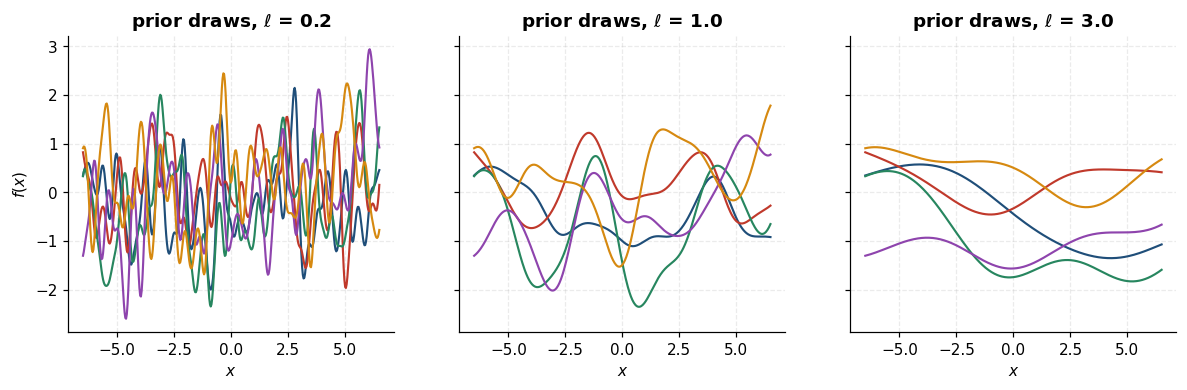

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, ell in zip(axes, [0.2, 1.0, 3.0]):
    prior_gp = GaussianProcessRegressor(length_scale=ell, signal_std=1.0, optimize=False)
    samples = prior_gp.sample_prior(grid, n_samples=5, random_state=1)
    ax.plot(grid, samples, lw=1.4)
    ax.set_title(fr"prior draws, $\ell$ = {ell}")
    ax.set_xlabel("$x$")
axes[0].set_ylabel("$f(x)$")
plt.show()

## 2. The posterior: conditioning on observations

The posterior mean interpolates the data (up to the noise level) and the
variance grows away from it -- the model knows where it is ignorant, which point
predictors cannot express.

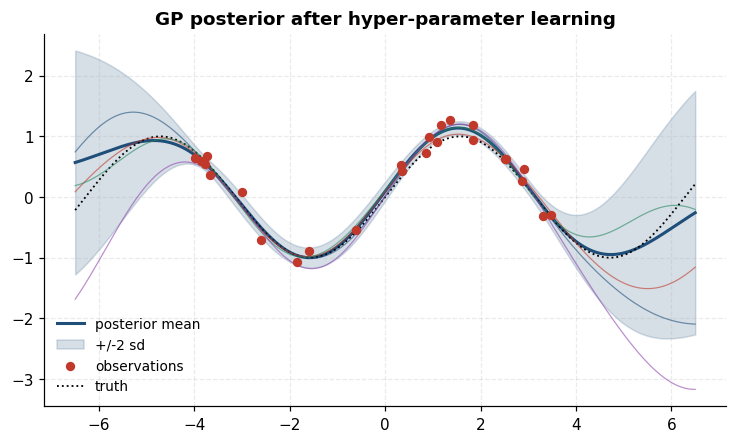

learned length scale : 1.818
learned signal std   : 1.102
learned noise std    : 0.136   (true: 0.150)
log marginal likelihood: 0.485


In [4]:
gp = GaussianProcessRegressor(length_scale=1.0, signal_std=1.0, noise_std=0.2,
                              n_restarts=3, random_state=0).fit(X, y)
mean, std = gp.predict(grid, return_std=True)

fig, ax = plt.subplots(figsize=(8, 4.4))
plot_gp(grid, mean, std, X, y, ax=ax, title="GP posterior after hyper-parameter learning")
ax.plot(grid, np.sin(grid), "k:", lw=1.2, label="truth")
ax.plot(grid, gp.sample_y(grid, n_samples=4, random_state=2), lw=0.8, alpha=0.6)
ax.legend(fontsize=9, loc="lower left")
plt.show()

print(f"learned length scale : {float(gp.length_scale_[0]):.3f}")
print(f"learned signal std   : {gp.signal_std_:.3f}")
print(f"learned noise std    : {gp.noise_std_:.3f}   (true: 0.150)")
print(f"log marginal likelihood: {gp.log_marginal_likelihood_value_:.3f}")

Note what happens outside $[-4, 4]$: the mean reverts to the prior (zero, plus
the data mean we subtracted) and the band widens to the prior width. A GP does
not extrapolate -- it admits ignorance.

## 3. The evidence surface

Rather than cross-validating the kernel parameters we maximise the marginal
likelihood directly. Its gradient is available analytically,

$$\frac{\partial}{\partial\theta_j}\log p
= \tfrac12\operatorname{tr}\Bigl[(\alpha\alpha^\top - K_y^{-1})\frac{\partial K_y}{\partial\theta_j}\Bigr],
\quad \alpha = K_y^{-1}y ,$$

which is what the L-BFGS optimiser inside `GaussianProcessRegressor` consumes.
The surface below shows why several restarts are worth the cost.

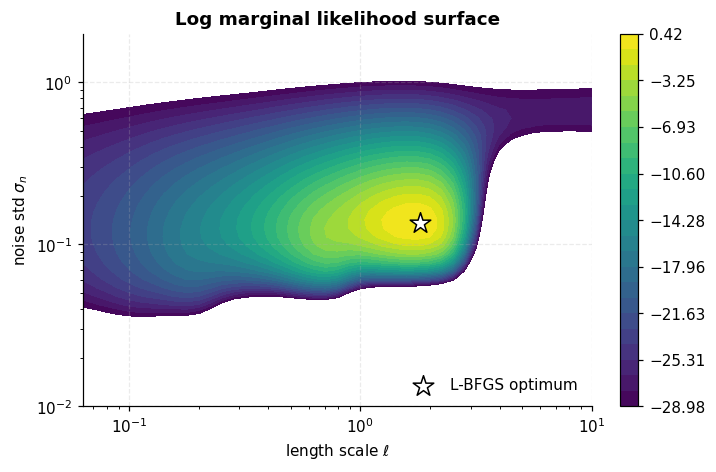

In [5]:
lengths = np.logspace(-1.2, 1.0, 45)
noises = np.logspace(-2.0, 0.3, 45)
LL = np.empty((len(noises), len(lengths)))
probe = GaussianProcessRegressor(optimize=False)
y_centered = y - y.mean()
for i, sn in enumerate(noises):
    for j, ell in enumerate(lengths):
        theta = np.log([ell, 1.0, sn])
        LL[i, j] = -probe._nll_and_grad(theta, X, y_centered)[0]

fig, ax = plt.subplots(figsize=(6.6, 4.4))
levels = np.linspace(np.percentile(LL, 55), LL.max(), 25)
cs = ax.contourf(lengths, noises, LL, levels=levels, cmap="viridis")
ax.scatter([gp.length_scale_[0]], [gp.noise_std_], marker="*", s=200,
           color="white", edgecolor="k", zorder=5, label="L-BFGS optimum")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"length scale $\ell$")
ax.set_ylabel(r"noise std $\sigma_n$")
ax.set_title("Log marginal likelihood surface")
ax.legend(loc="lower right")
fig.colorbar(cs, ax=ax, fraction=0.046)
plt.show()

## 4. Why the evidence is not just "fit"

Compare three hyper-parameter settings. The over-flexible one fits the training
data best yet scores *worse* on the evidence, because $\log|K_y|$ charges for
the extra flexibility.

In [6]:
print(f"{'setting':<26}{'train MSE':>11}{'log evidence':>15}")
for label, kwargs in [
    ("too smooth (l=5, s=0.5)", dict(length_scale=5.0, noise_std=0.5)),
    ("learned", dict(length_scale=float(gp.length_scale_[0]),
                     signal_std=gp.signal_std_, noise_std=gp.noise_std_)),
    ("too wiggly (l=0.1, s=0.01)", dict(length_scale=0.1, noise_std=0.01)),
]:
    fixed = GaussianProcessRegressor(optimize=False, **kwargs).fit(X, y)
    print(f"{label:<26}{mse(y, fixed.predict(X)):>11.4f}"
          f"{fixed.log_marginal_likelihood_value_:>15.2f}")

setting                     train MSE   log evidence
too smooth (l=5, s=0.5)        0.3458         -28.12
learned                        0.0138           0.48
too wiggly (l=0.1, s=0.01)     0.0004        -101.69


## 5. Are the error bars honest?

A calibrated posterior should contain roughly 95% of held-out targets inside
$\mu \pm 1.96\sqrt{\operatorname{Var} + \sigma_n^2}$. Note the noise variance
must be added back: the posterior over $f$ is narrower than the predictive
distribution over $y$.

In [7]:
X_new, y_new = make_sine(300, noise=0.15, x_range=(-4.0, 4.0), random_state=99)
mu, sd = gp.predict(X_new, return_std=True)
sd_pred = np.sqrt(sd**2 + gp.noise_std_**2)
for z, nominal in [(1.0, 0.683), (1.96, 0.95)]:
    cov = interval_coverage(y_new, mu - z * sd_pred, mu + z * sd_pred)
    print(f"+/-{z:.2f} sd -> empirical coverage {cov:.3f} (nominal {nominal:.3f})")

+/-1.00 sd -> empirical coverage 0.650 (nominal 0.683)
+/-1.96 sd -> empirical coverage 0.907 (nominal 0.950)


The one-sigma band is close to nominal, but the 95% band under-covers slightly
here: with only 25 observations the learned $\sigma_n$ is itself uncertain, and
the GP's guarantee is conditional on the model being correct. Notebook 08 shows
how to wrap *any* predictor -- GP included -- in intervals whose coverage holds
without that assumption.

## 6. ARD: length-scales as feature relevance

With one length-scale per input dimension (*automatic relevance determination*),
an irrelevant feature is switched off by driving its length-scale to infinity --
the evidence does this on its own.

In [8]:
rng = np.random.default_rng(3)
X2 = rng.uniform(-3, 3, size=(150, 3))
y2 = np.sin(X2[:, 0]) + 0.3 * X2[:, 1]          # third column is noise
gp_ard = GaussianProcessRegressor(length_scale=[1.0, 1.0, 1.0], noise_std=0.1,
                                  n_restarts=3, random_state=0).fit(X2, y2)

for j, ell in enumerate(gp_ard.length_scale_):
    role = ["sin(x0) - highly relevant", "0.3*x1 - mildly relevant", "irrelevant"][j]
    print(f"feature {j}: length scale {ell:8.3f}   ({role})")

feature 0: length scale    4.156   (sin(x0) - highly relevant)
feature 1: length scale  241.042   (0.3*x1 - mildly relevant)
feature 2: length scale 10000.000   (irrelevant)


The relevance ordering falls straight out of the fitted length-scales: short for
the strongly non-linear input, longer for the near-linear one, and very long for
the feature that carries no signal.

## 7. What to take away

1. GPs return a full predictive distribution, not a point estimate, and the
   uncertainty is meaningful outside the data.
2. The marginal likelihood balances fit against complexity automatically, so
   kernel hyper-parameters can be *learned* instead of cross-validated.
3. Analytic gradients make that optimisation cheap -- but the surface is
   multi-modal, hence random restarts.
4. ARD turns length-scales into an interpretable relevance measure.
5. Exact inference costs $O(n^3)$ time and $O(n^2)$ memory through the Cholesky
   factor; sparse/inducing-point approximations are the standard remedy.

**Next:** notebook 05 moves from exact Gaussian inference to an iterative lower
bound -- the EM algorithm.